<a href="https://colab.research.google.com/github/RAHUL-REDDY-A/ML/blob/main/ml_lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB 10: FEATURE SELECTION, DIMENSIONALITY REDUCTION & EXPLAINABLE AI

Loading and preprocessing data...
Dataset shape: (50000, 15)
Features: ['Age', 'Gender', 'Occupation', 'Country', 'Severity', 'Consultation_History', 'Stress_Level', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage', 'Diet_Quality', 'Smoking_Habit', 'Alcohol_Consumption', 'Medication_Usage']
Target distribution:
Mental_Health_Condition
0    25003
1    24997
Name: count, dtype: int64

--------------------------------------------------------------------------------
A1: CORRELATION ANALYSIS
--------------------------------------------------------------------------------


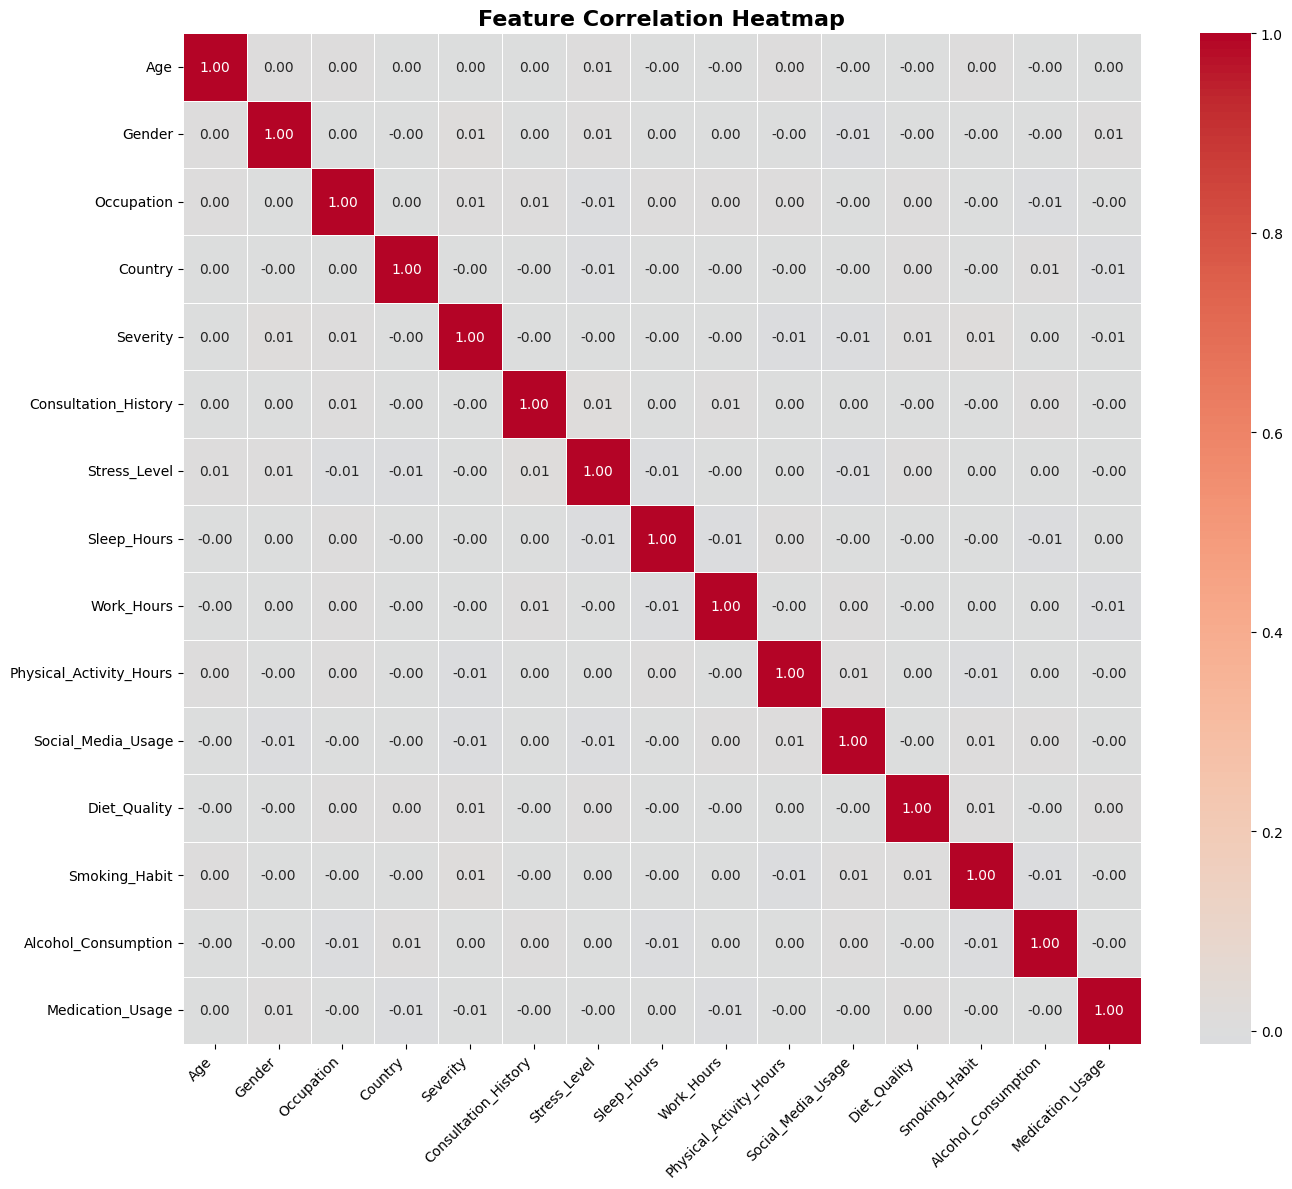

Correlation heatmap saved as 'correlation_heatmap.png'

No highly correlated feature pairs found (|r| > 0.7)

--------------------------------------------------------------------------------
A2: PCA WITH 99% VARIANCE
--------------------------------------------------------------------------------
Number of components for 99% variance: 15
Explained variance ratios: [0.06881907 0.06812473 0.06791645 0.06767979 0.06741476 0.0672396
 0.06699145 0.06685283 0.06661493 0.06610555 0.06584945 0.0655865
 0.06513101 0.065008   0.06466589]

Model Performance with 99% Variance PCA:
  Random Forest: Accuracy = 0.4984
  Logistic Regression: Accuracy = 0.4944

--------------------------------------------------------------------------------
A3: PCA WITH 95% VARIANCE
--------------------------------------------------------------------------------
Number of components for 95% variance: 15
Explained variance ratios: [0.06881907 0.06812473 0.06791645 0.06767979 0.06741476 0.0672396
 0.06699145 0.06685283 0

<Figure size 1000x800 with 0 Axes>

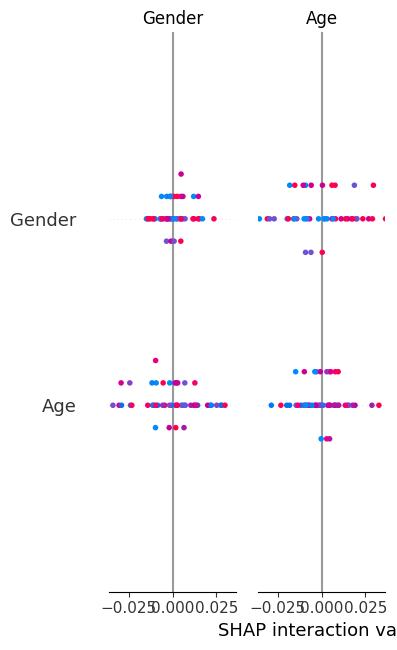


LIME vs SHAP - COMPARISON
LIME Characteristics:
  - Local explanation (explains individual predictions)
  - Model-agnostic (works with any model)
  - Uses perturbations to understand feature impact
  - Provides interpretable linear approximation
  - Better for explaining specific instances

SHAP Characteristics:
  - Based on game theory (Shapley values)
  - Provides both local and global explanations
  - Consistent and theoretically sound
  - Shows feature importance across dataset
  - Better for overall model understanding

Usage Suitability:
  - Use LIME when: Need to explain why a specific prediction was made
  - Use SHAP when: Need comprehensive model behavior understanding
  - Both can complement each other for thorough analysis

LAB 10 ANALYSIS COMPLETED SUCCESSFULLY


In [4]:
"""
Lab 10: Feature Selection, Dimensionality Reduction, and Explainable AI
Dataset: Mental Health Dataset (MHDS.csv)
Subject: 23CSE301
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap
from lime.lime_tabular import LimeTabularExplainer
import warnings
warnings.filterwarnings('ignore')


# ==================== DATA LOADING AND PREPROCESSING ====================

def load_and_preprocess_data(filepath):
    """
    Load and preprocess the mental health dataset

    Args:
        filepath: Path to the CSV file

    Returns:
        X: Feature matrix
        y: Target variable
        feature_names: List of feature names
        label_encoders: Dictionary of label encoders for categorical variables
    """
    df = pd.read_csv(filepath)

    # Create a copy for processing
    df_processed = df.copy()

    # Drop User_ID as it's not a feature
    if 'User_ID' in df_processed.columns:
        df_processed = df_processed.drop('User_ID', axis=1)

    # Define target variable (Mental_Health_Condition)
    target_column = 'Mental_Health_Condition'

    # Encode categorical variables
    label_encoders = {}
    categorical_columns = df_processed.select_dtypes(include=['object']).columns

    for col in categorical_columns:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le

    # Separate features and target
    X = df_processed.drop(target_column, axis=1)
    y = df_processed[target_column]

    feature_names = X.columns.tolist()

    return X, y, feature_names, label_encoders


# ==================== A1: CORRELATION ANALYSIS ====================

def perform_correlation_analysis(X, feature_names):
    """
    Perform correlation analysis and create heatmap

    Args:
        X: Feature matrix
        feature_names: List of feature names

    Returns:
        correlation_matrix: Correlation matrix
    """
    # Calculate correlation matrix
    correlation_matrix = X.corr()

    # Create heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                xticklabels=feature_names, yticklabels=feature_names,
                center=0, linewidths=0.5)
    plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    return correlation_matrix


# ==================== A2: PCA WITH 99% VARIANCE ====================

def apply_pca_and_evaluate(X_train, X_test, y_train, y_test, variance_ratio=0.99):
    """
    Apply PCA with specified variance retention and evaluate models

    Args:
        X_train, X_test: Train and test features
        y_train, y_test: Train and test targets
        variance_ratio: Variance to retain (0.99 for 99%)

    Returns:
        results: Dictionary containing PCA components, transformed data, and model results
    """
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply PCA
    pca = PCA(n_components=variance_ratio, svd_solver='full')
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Get explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    results = {
        'n_components': pca.n_components_,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_variance': cumulative_variance,
        'X_train_pca': X_train_pca,
        'X_test_pca': X_test_pca,
        'pca_model': pca,
        'scaler': scaler
    }

    # Train and evaluate models
    # Model 1: Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_pca, y_train)
    rf_pred = rf_model.predict(X_test_pca)
    rf_accuracy = accuracy_score(y_test, rf_pred)

    # Model 2: Logistic Regression
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_pca, y_train)
    lr_pred = lr_model.predict(X_test_pca)
    lr_accuracy = accuracy_score(y_test, lr_pred)

    results['models'] = {
        'Random Forest': {'model': rf_model, 'accuracy': rf_accuracy, 'predictions': rf_pred},
        'Logistic Regression': {'model': lr_model, 'accuracy': lr_accuracy, 'predictions': lr_pred}
    }

    return results


# ==================== A3: PCA WITH 95% VARIANCE ====================

def compare_pca_results(results_99, results_95):
    """
    Compare PCA results with different variance thresholds

    Args:
        results_99: Results from 99% variance PCA
        results_95: Results from 95% variance PCA

    Returns:
        comparison_df: DataFrame with comparison metrics
    """
    comparison_data = []

    for variance_type, results in [('99% Variance', results_99), ('95% Variance', results_95)]:
        for model_name, model_data in results['models'].items():
            comparison_data.append({
                'Variance Type': variance_type,
                'N Components': results['n_components'],
                'Model': model_name,
                'Accuracy': model_data['accuracy']
            })

    comparison_df = pd.DataFrame(comparison_data)
    return comparison_df


# ==================== A4: SEQUENTIAL FEATURE SELECTION ====================

def sequential_feature_selection(X_train, X_test, y_train, y_test, n_features=5):
    """
    Apply sequential feature selection and evaluate models

    Args:
        X_train, X_test: Train and test features
        y_train, y_test: Train and test targets
        n_features: Number of features to select

    Returns:
        results: Dictionary containing selected features and model results
    """
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    results = {}

    # Sequential Feature Selection with Random Forest
    rf_estimator = RandomForestClassifier(n_estimators=50, random_state=42)
    sfs = SequentialFeatureSelector(rf_estimator, n_features_to_select=n_features,
                                     direction='forward', cv=3, n_jobs=-1)
    sfs.fit(X_train_scaled, y_train)

    # Get selected features
    selected_features = sfs.get_support()
    selected_feature_names = X_train.columns[selected_features].tolist()

    # Transform data
    X_train_sfs = sfs.transform(X_train_scaled)
    X_test_sfs = sfs.transform(X_test_scaled)

    results['selected_features'] = selected_feature_names
    results['n_features'] = n_features

    # Train and evaluate models with selected features
    # Model 1: Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_sfs, y_train)
    rf_pred = rf_model.predict(X_test_sfs)
    rf_accuracy = accuracy_score(y_test, rf_pred)

    # Model 2: Logistic Regression
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_sfs, y_train)
    lr_pred = lr_model.predict(X_test_sfs)
    lr_accuracy = accuracy_score(y_test, lr_pred)

    results['models'] = {
        'Random Forest': {'model': rf_model, 'accuracy': rf_accuracy, 'predictions': rf_pred},
        'Logistic Regression': {'model': lr_model, 'accuracy': lr_accuracy, 'predictions': lr_pred}
    }

    return results


# ==================== A5: EXPLAINABLE AI (LIME & SHAP) ====================

def apply_lime_explanation(model, X_train, X_test, feature_names, class_names, sample_idx=0):
    """
    Apply LIME for model explanation

    Args:
        model: Trained model
        X_train: Training features
        X_test: Test features
        feature_names: List of feature names
        class_names: List of class names
        sample_idx: Index of sample to explain

    Returns:
        explanation: LIME explanation object
    """
    # Create LIME explainer
    explainer = LimeTabularExplainer(
        X_train,
        feature_names=feature_names,
        class_names=class_names,
        mode='classification',
        random_state=42
    )

    # Explain a prediction
    explanation = explainer.explain_instance(
        X_test[sample_idx],
        model.predict_proba,
        num_features=len(feature_names)
    )

    return explanation


def apply_shap_explanation(model, X_train, X_test, feature_names):
    """
    Apply SHAP for model explanation

    Args:
        model: Trained model
        X_train: Training features
        X_test: Test features
        feature_names: List of feature names

    Returns:
        shap_values: SHAP values
        explainer: SHAP explainer object
    """
    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values
    shap_values = explainer.shap_values(X_test)

    return shap_values, explainer


def visualize_shap_summary(shap_values, X_test, feature_names):
    """
    Create SHAP summary plot

    Args:
        shap_values: SHAP values
        X_test: Test features
        feature_names: List of feature names
    """
    plt.figure(figsize=(10, 8))

    # For binary classification, use shap_values[1]
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_test, feature_names=feature_names, show=False)
    else:
        shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)

    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()


# ==================== MAIN PROGRAM ====================

if __name__ == "__main__":

    print("="*80)
    print("LAB 10: FEATURE SELECTION, DIMENSIONALITY REDUCTION & EXPLAINABLE AI")
    print("="*80)
    print()

    # Load and preprocess data
    print("Loading and preprocessing data...")
    filepath = 'MHDS.csv'
    X, y, feature_names, label_encoders = load_and_preprocess_data(filepath)
    print(f"Dataset shape: {X.shape}")
    print(f"Features: {feature_names}")
    print(f"Target distribution:\n{y.value_counts()}")
    print()

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ==================== A1: CORRELATION ANALYSIS ====================
    print("-"*80)
    print("A1: CORRELATION ANALYSIS")
    print("-"*80)
    correlation_matrix = perform_correlation_analysis(X, feature_names)
    print("Correlation heatmap saved as 'correlation_heatmap.png'")
    print()

    # Find highly correlated features
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                high_corr_pairs.append((
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    correlation_matrix.iloc[i, j]
                ))

    if high_corr_pairs:
        print("Highly correlated feature pairs (|r| > 0.7):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"  {feat1} <-> {feat2}: {corr:.3f}")
    else:
        print("No highly correlated feature pairs found (|r| > 0.7)")
    print()

    # ==================== A2: PCA WITH 99% VARIANCE ====================
    print("-"*80)
    print("A2: PCA WITH 99% VARIANCE")
    print("-"*80)
    results_99 = apply_pca_and_evaluate(X_train, X_test, y_train, y_test, variance_ratio=0.99)
    print(f"Number of components for 99% variance: {results_99['n_components']}")
    print(f"Explained variance ratios: {results_99['explained_variance_ratio']}")
    print()
    print("Model Performance with 99% Variance PCA:")
    for model_name, model_data in results_99['models'].items():
        print(f"  {model_name}: Accuracy = {model_data['accuracy']:.4f}")
    print()

    # ==================== A3: PCA WITH 95% VARIANCE ====================
    print("-"*80)
    print("A3: PCA WITH 95% VARIANCE")
    print("-"*80)
    results_95 = apply_pca_and_evaluate(X_train, X_test, y_train, y_test, variance_ratio=0.95)
    print(f"Number of components for 95% variance: {results_95['n_components']}")
    print(f"Explained variance ratios: {results_95['explained_variance_ratio']}")
    print()
    print("Model Performance with 95% Variance PCA:")
    for model_name, model_data in results_95['models'].items():
        print(f"  {model_name}: Accuracy = {model_data['accuracy']:.4f}")
    print()

    # Compare PCA results
    comparison_df = compare_pca_results(results_99, results_95)
    print("Comparison of PCA Results:")
    print(comparison_df.to_string(index=False))
    print()

    # ==================== A4: SEQUENTIAL FEATURE SELECTION ====================
    print("-"*80)
    print("A4: SEQUENTIAL FEATURE SELECTION")
    print("-"*80)
    n_features_to_select = min(5, X_train.shape[1] - 1)
    sfs_results = sequential_feature_selection(X_train, X_test, y_train, y_test,
                                                n_features=n_features_to_select)
    print(f"Number of features selected: {sfs_results['n_features']}")
    print(f"Selected features: {sfs_results['selected_features']}")
    print()
    print("Model Performance with Sequential Feature Selection:")
    for model_name, model_data in sfs_results['models'].items():
        print(f"  {model_name}: Accuracy = {model_data['accuracy']:.4f}")
    print()

    # Compare all methods
    print("="*80)
    print("COMPARISON OF ALL FEATURE REDUCTION METHODS")
    print("="*80)
    all_results = []

    # Baseline (all features)
    X_train_scaled = StandardScaler().fit_transform(X_train)
    X_test_scaled = StandardScaler().fit_transform(X_test)
    rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_baseline.fit(X_train_scaled, y_train)
    baseline_acc = accuracy_score(y_test, rf_baseline.predict(X_test_scaled))
    all_results.append(['Baseline (All Features)', X_train.shape[1], baseline_acc])

    # PCA results
    all_results.append(['PCA 99%', results_99['n_components'],
                       results_99['models']['Random Forest']['accuracy']])
    all_results.append(['PCA 95%', results_95['n_components'],
                       results_95['models']['Random Forest']['accuracy']])
    all_results.append(['SFS', sfs_results['n_features'],
                       sfs_results['models']['Random Forest']['accuracy']])

    comparison_all = pd.DataFrame(all_results,
                                  columns=['Method', 'N Features', 'RF Accuracy'])
    print(comparison_all.to_string(index=False))
    print()

    # ==================== A5: EXPLAINABLE AI (LIME & SHAP) ====================
    print("-"*80)
    print("A5: EXPLAINABLE AI - LIME & SHAP")
    print("-"*80)

    # Use the best model (Random Forest with all features for demonstration)
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    X_train_scaled = StandardScaler().fit_transform(X_train)
    X_test_scaled = StandardScaler().fit_transform(X_test)
    rf_model.fit(X_train_scaled, y_train)

    print("Applying LIME explanation...")
    class_names = ['No Mental Health Condition', 'Has Mental Health Condition']
    lime_exp = apply_lime_explanation(
        rf_model,
        X_train_scaled,
        X_test_scaled,
        feature_names,
        class_names,
        sample_idx=0
    )
    print("LIME Explanation for first test sample:")
    print("Feature importance:")
    for feat, weight in lime_exp.as_list():
        print(f"  {feat}: {weight:.4f}")
    print()

    print("Applying SHAP explanation...")
    shap_values, shap_explainer = apply_shap_explanation(
        rf_model,
        X_train_scaled[:100],  # Use subset for faster computation
        X_test_scaled[:50],
        feature_names
    )
    print("SHAP summary plot saved as 'shap_summary_plot.png'")
    visualize_shap_summary(shap_values, X_test_scaled[:50], feature_names)
    print()

    print("="*80)
    print("LIME vs SHAP - COMPARISON")
    print("="*80)
    print("LIME Characteristics:")
    print("  - Local explanation (explains individual predictions)")
    print("  - Model-agnostic (works with any model)")
    print("  - Uses perturbations to understand feature impact")
    print("  - Provides interpretable linear approximation")
    print("  - Better for explaining specific instances")
    print()
    print("SHAP Characteristics:")
    print("  - Based on game theory (Shapley values)")
    print("  - Provides both local and global explanations")
    print("  - Consistent and theoretically sound")
    print("  - Shows feature importance across dataset")
    print("  - Better for overall model understanding")
    print()
    print("Usage Suitability:")
    print("  - Use LIME when: Need to explain why a specific prediction was made")
    print("  - Use SHAP when: Need comprehensive model behavior understanding")
    print("  - Both can complement each other for thorough analysis")
    print()

    print("="*80)
    print("LAB 10 ANALYSIS COMPLETED SUCCESSFULLY")
    print("="*80)